# Adversarial Drift Detection — Instance-Based Poisoning Attack

Reproduces the left panels of Fig. 7 in:  
> Kuppa & Le-Khac (2022) *"Learn to adapt: Robust drift detection in security domain."*

## Threat model (Section 3.1)
The attacker has **no** knowledge of classifier architecture, retraining intervals, or defense methods.  
The attacker **does** have: the training/test data distribution, an inference API, the feature transformation functions, and the feature set.  
The attacker **is** capable of manipulating training data.

## Attack protocol (training-data poisoning)
For each injection ratio $L_{inst} \in \{0.05, 0.10, 0.15, 0.20, 0.25\}$:
1. The attacker trains a surrogate MLP on accessible data and uses ART's PGD to generate adversarial versions of novel-class samples — making them look like known-class samples (targeted label-flip). No gradients from the deployed model are used.
2. These disguised samples (labeled as a known class) are injected into the **training** data using bootstrap-bagging across time windows. This corrupts the NCM class prototype means.
3. The detector is **retrained** on the poisoned training data.
4. Accuracy is measured on the **clean test set**. Accuracy drop = F1(clean) − F1(poisoned).

## 1. Imports & configuration

In [ ]:
import os
import sys

sys.path.insert(0, os.path.join(os.path.abspath(''), '../..'))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from art.attacks.evasion import ProjectedGradientDescent
from art.estimators.classification import PyTorchClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from src.detectors.contrastive_ncm import (
    ContrastiveNCMDetector,
    DriftAutoencoder,
    NCMClassifier,
    train_plain_autoencoder,
)

DATA_DIR   = os.path.join(os.path.abspath(''), '../..', 'data', 'CICIDS2017_Engelen')
EPOCHS             = 100
SURROGATE_EPOCHS   = 10
LR                 = 0.0001
BATCH_SIZE         = 256
TEST_SIZE          = 0.25
CALIBRATION_QUANTILE = 0.95
DROPPED_CLASSES = ["DoS", "Patator"]
RANDOM_SEED = 42
DEVICE             = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PGD_EPSILON = 0.3
PGD_ALPHA   = 0.01
PGD_STEPS   = 40

INJECTION_RATIOS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
N_BAGS = 5

print(f'Device: {DEVICE}')
print(f"Data dir     : {DATA_DIR}")
print(f"Dropped      : {DROPPED_CLASSES}")

Device: cpu


## 2. Load & preprocess data

In [ ]:
DAY_FILES = [
    'Monday-WorkingHours.csv',
    'Tuesday-WorkingHours.csv',
    'Wednesday-WorkingHours.csv',
    'Thursday-WorkingHours.csv',
    'Friday-WorkingHours.csv',
]

print('Loading data...')
dfs = [pd.read_csv(os.path.join(DATA_DIR, f)) for f in DAY_FILES]
df  = pd.concat(dfs, ignore_index=True)
print(f'  Total rows: {len(df):,}')

df.drop(
    columns=["Flow ID", "Src IP", "Src Port", "Dst IP", "Dst Port", "Timestamp"],
    inplace=True,
    errors="ignore",
)

df["Label"] = df["Label"].apply(lambda x: "BENIGN" if x.endswith("- Attempted") else x)

LABEL_MAP = {
    "DoS Hulk": "DoS",
    "DoS GoldenEye": "DoS",
    "DoS slowloris": "DoS",
    "DoS Slowhttptest": "DoS",
    "Web Attack - Brute Force": "Web Attack",
    "Web Attack - XSS": "Web Attack",
    "Web Attack - Sql Injection": "Web Attack",
    "FTP-Patator": "Patator",
    "SSH-Patator": "Patator",
}
df['Label'] = df['Label'].replace(LABEL_MAP)

print("Class distribution after consolidation:")
print(df["Label"].value_counts().to_string())

feature_cols = [c for c in df.columns if c != 'Label']
X_raw = df[feature_cols].copy()
y_str = df['Label'].values

X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
X_raw.dropna(axis=1, how='all', inplace=True)
X_raw.fillna(X_raw.mean(), inplace=True)

print(f"Feature count after cleaning: {X_raw.shape[1]}")

scaler = StandardScaler()
X = scaler.fit_transform(X_raw).astype(np.float32)

le_full = LabelEncoder()
y_all = le_full.fit_transform(y_str)

print(f"All classes: {list(le_full.classes_)}")

Loading data...
  Total rows: 2,100,814
Feature count: 79  |  All classes: ['BENIGN', 'Bot', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'Patator', 'PortScan', 'Web Attack']


## 3. Train / test split

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_all, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_all
)

dropped_ids = np.array([le_full.transform([c])[0] for c in DROPPED_CLASSES])

train_known_mask = ~np.isin(y_tr, dropped_ids)
X_tr_known = X_tr[train_known_mask]
y_tr_known = y_tr[train_known_mask]

le_train     = LabelEncoder()
y_tr_reenc   = le_train.fit_transform(y_tr_known).astype(np.int64)
num_train_classes = len(le_train.classes_)
input_dim    = X.shape[1]

print(f"Dropped (novel) classes : {DROPPED_CLASSES}")
print(f"Training classes ({num_train_classes}): {[le_full.classes_[i] for i in le_train.classes_]}")

# Novel-class training samples — attacker's poison pool (accessible via data distribution)
train_novel_mask = np.isin(y_tr, dropped_ids)
X_tr_novel = X_tr[train_novel_mask]

# Clean test set — never touched by the attack
novel_test_mask = np.isin(y_te, dropped_ids)
X_te_novel  = X_te[novel_test_mask]
X_te_known  = X_te[~novel_test_mask]
y_te_binary = novel_test_mask.astype(int)
X_te_full   = np.vstack([X_te_known, X_te_novel])

print(f'Dropped classes          : {DROPPED_CLASSES}')
print(f'Training classes         : {num_train_classes}')
print(f'Known train samples      : {len(X_tr_known):,}')
print(f'Novel train samples      : {len(X_tr_novel):,}  (attacker poison pool)')
print(f'Test samples             : {len(X_te):,}')
print(f'Novel (drifted) test     : {novel_test_mask.sum():,}')


def make_loader(X_arr, y_arr, shuffle=True):
    return DataLoader(
        TensorDataset(torch.from_numpy(X_arr), torch.from_numpy(y_arr)),
        batch_size=BATCH_SIZE, shuffle=shuffle,
    )

train_loader_clean = make_loader(X_tr_known, y_tr_reenc)

Dropped classes          : ['DDoS', 'PortScan']
Training classes         : 7
Known train samples      : 1,384,905
Novel train samples      : 190,705  (attacker poison pool)
Test samples             : 525,204
Novel (drifted) test     : 63,569


## 4. Train attacker surrogate (black-box threat model)

The attacker trains a plain MLP on the accessible data distribution. They do **not** know the deployed architecture or defense method.

In [13]:
class SurrogateMLP(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, 64),     nn.ReLU(),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        return self.net(x)


surrogate     = SurrogateMLP(input_dim, num_train_classes).to(DEVICE)
surrogate_opt = torch.optim.Adam(surrogate.parameters(), lr=LR)
ce_loss       = nn.CrossEntropyLoss()

surrogate.train()
for epoch in range(SURROGATE_EPOCHS):
    epoch_loss = 0.0
    for x_b, y_b in train_loader_clean:
        x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
        surrogate_opt.zero_grad()
        loss = ce_loss(surrogate(x_b), y_b)
        loss.backward()
        surrogate_opt.step()
        epoch_loss += loss.item()
        print(f'Batch loss={loss.item():.4f}\r', end="")
    print(f'  epoch {epoch+1}/{SURROGATE_EPOCHS}  loss={epoch_loss/len(train_loader_clean):.4f}')
surrogate.eval()
print('Surrogate training complete.')

  epoch 1/10  loss=0.0804
  epoch 2/10  loss=0.0124
  epoch 3/10  loss=0.0085
  epoch 4/10  loss=0.0074
  epoch 5/10  loss=0.0067
  epoch 6/10  loss=0.0061
  epoch 7/10  loss=0.0057
  epoch 8/10  loss=0.0053
  epoch 9/10  loss=0.0050
  epoch 10/10  loss=0.0046
Surrogate training complete.


## 5. Generate adversarial poison samples via ART PGD

PGD runs against the surrogate only — no gradients from the deployed detectors.  
Target: push each novel-class sample toward its nearest known-class centroid.

In [14]:
feature_min = float(X_tr_known.min())
feature_max = float(X_tr_known.max())

surrogate_art = PyTorchClassifier(
    model=surrogate,
    loss=ce_loss,
    optimizer=surrogate_opt,
    input_shape=(input_dim,),
    nb_classes=num_train_classes,
    clip_values=(feature_min, feature_max),
    device_type='gpu' if DEVICE.type == 'cuda' else 'cpu',
)

pgd = ProjectedGradientDescent(
    estimator=surrogate_art,
    norm=np.inf,
    eps=PGD_EPSILON,
    eps_step=PGD_ALPHA,
    max_iter=PGD_STEPS,
    targeted=True,
    batch_size=512,
    verbose=True,
)

# Nearest known-class centroid: O(N_novel × C × D) — much faster than 1-NN
print('Finding target known class via nearest centroid...')
centroids = np.stack([
    X_tr_known[y_tr_reenc == c].mean(axis=0) for c in range(num_train_classes)
])  # (C, D)
dists          = np.linalg.norm(X_tr_novel[:, None, :] - centroids[None, :, :], axis=2)
poison_targets = dists.argmin(axis=1).astype(np.int32)
poison_targets_onehot = np.eye(num_train_classes, dtype=np.float32)[poison_targets]

print('Generating adversarial poison samples (PGD on surrogate)...')
X_tr_novel_adv = pgd.generate(x=X_tr_novel, y=poison_targets_onehot)
print(f'  Poison pool ready: {X_tr_novel_adv.shape[0]:,} samples')

Finding target known class via nearest centroid...
Generating adversarial poison samples (PGD on surrogate)...


  Poison pool ready: 190,705 samples


## 6. Helper functions

In [15]:
def inject_poison_into_training(X_clean, y_clean, X_poison, y_poison_labels,
                                 l_inst, n_bags=N_BAGS, seed=RANDOM_SEED):
    """
    Inject adversarial novel-class samples (labeled as known classes) into
    training using bootstrap-bagging across time windows (paper Section 4).
    l_inst fraction of the poison pool is drawn per bag and appended.
    """
    rng = np.random.RandomState(seed)
    bags_X, bags_y = [], []
    for bag_indices in np.array_split(np.arange(len(X_clean)), n_bags):
        bag_X = X_clean[bag_indices]
        bag_y = y_clean[bag_indices]
        n_inject = max(1, int(len(X_poison) * l_inst / n_bags))
        chosen   = rng.choice(len(X_poison), size=n_inject, replace=True)
        bag_X    = np.vstack([bag_X, X_poison[chosen]])
        bag_y    = np.concatenate([bag_y, y_poison_labels[chosen]])
        bags_X.append(bag_X)
        bags_y.append(bag_y)
    return np.vstack(bags_X), np.concatenate(bags_y)


def evaluate_detector(X_test, y_binary, threshold, autoencoder, ncm):
    """Return (precision, recall, F1) for a given AE + NCM detector."""
    autoencoder.eval()
    with torch.no_grad():
        h = autoencoder.encode(torch.from_numpy(X_test).to(DEVICE))
    dists  = ncm._compute_distance(h).min(dim=1).values.cpu().numpy()
    y_pred = (dists > threshold).astype(int)
    return (
        precision_score(y_binary, y_pred, zero_division=0),
        recall_score(y_binary, y_pred, zero_division=0),
        f1_score(y_binary, y_pred, zero_division=0),
    )

print('Helper functions defined.')

Helper functions defined.


## 7. Sweep injection ratios

For each ratio: inject poison into training → retrain both detectors → evaluate on clean test set.

In [16]:
results_c, results_p = [], []

for l_inst in INJECTION_RATIOS:
    print(f'\n── L_inst = {l_inst:.2f} ' + '─' * 40)

    if l_inst == 0.0:
        X_tr_poisoned = X_tr_known
        y_tr_poisoned = y_tr_reenc
    else:
        X_tr_poisoned, y_tr_poisoned = inject_poison_into_training(
            X_tr_known, y_tr_reenc, X_tr_novel_adv, poison_targets, l_inst
        )

    poisoned_loader = make_loader(X_tr_poisoned, y_tr_poisoned.astype(np.int64))

    # ── ContrastiveNCM ────────────────────────────────────────────────────────
    det = ContrastiveNCMDetector(
        input_dim=input_dim, hidden_dim=64, latent_dim=32,
        drift_threshold=1.0, concept_threshold=3.5, device=DEVICE,
    )
    det.fit(poisoned_loader, epochs=EPOCHS, lr=LR, num_classes=num_train_classes)

    cal_size = min(5000, len(X_tr_poisoned))
    X_cal    = torch.from_numpy(X_tr_poisoned[:cal_size])
    _, _, cal_dists = det.detect(X_cal)
    det.drift_threshold = float(torch.quantile(cal_dists, CALIBRATION_QUANTILE).item())

    # ── Plain AE + NCM ────────────────────────────────────────────────────────
    pae = DriftAutoencoder(input_dim=input_dim, hidden_dim=64, latent_dim=32).to(DEVICE)
    train_plain_autoencoder(pae, poisoned_loader, epochs=EPOCHS, lr=LR)

    pae.eval()
    all_h, all_y = [], []
    with torch.no_grad():
        for x_b, y_b in poisoned_loader:
            all_h.append(pae.encode(x_b.to(DEVICE)))
            all_y.append(y_b)
    ncm_p = NCMClassifier(lambda_1=0.1)
    ncm_p.fit(torch.cat(all_h), torch.cat(all_y), num_train_classes)

    with torch.no_grad():
        cal_h_p = pae.encode(X_cal.to(DEVICE))
    plain_thr = float(
        ncm_p._compute_distance(cal_h_p).min(dim=1).values.cpu()
        .quantile(CALIBRATION_QUANTILE).item()
    )

    # ── Evaluate on clean test set ────────────────────────────────────────────
    p_c, r_c, f_c = evaluate_detector(X_te_full, y_te_binary, det.drift_threshold, det.autoencoder, det.ncm)
    p_p, r_p, f_p = evaluate_detector(X_te_full, y_te_binary, plain_thr, pae, ncm_p)

    results_c.append((l_inst, p_c, r_c, f_c))
    results_p.append((l_inst, p_p, r_p, f_p))
    print(f'  ContrastiveNCM  P={p_c:.3f} R={r_c:.3f} F1={f_c:.3f}')
    print(f'  Plain AE        P={p_p:.3f} R={r_p:.3f} F1={f_p:.3f}')


── L_inst = 0.00 ────────────────────────────────────────
Epoch 1/100 | Loss: 5.8630
Epoch 2/100 | Loss: 5.5379
Epoch 3/100 | Loss: 5.4635
Epoch 4/100 | Loss: 5.4120
Epoch 5/100 | Loss: 5.3731
Epoch 6/100 | Loss: 5.3505
Epoch 7/100 | Loss: 5.3356
Epoch 8/100 | Loss: 5.3237
Epoch 9/100 | Loss: 5.3148
Epoch 10/100 | Loss: 5.3065
Epoch 11/100 | Loss: 5.2995
Epoch 12/100 | Loss: 5.2968
Epoch 13/100 | Loss: 5.2915
Epoch 14/100 | Loss: 5.2868
Epoch 15/100 | Loss: 5.2842
Epoch 16/100 | Loss: 5.2804
Epoch 17/100 | Loss: 5.2793
Epoch 18/100 | Loss: 5.2772
Epoch 19/100 | Loss: 5.2748
Epoch 20/100 | Loss: 5.2741
Epoch 21/100 | Loss: 5.2710
Epoch 22/100 | Loss: 5.2697
Epoch 23/100 | Loss: 5.2683
Epoch 24/100 | Loss: 5.2667
Epoch 25/100 | Loss: 5.2664
Epoch 26/100 | Loss: 5.2624
Epoch 27/100 | Loss: 5.2619
Epoch 28/100 | Loss: 5.2599
Epoch 29/100 | Loss: 5.2587
Epoch 30/100 | Loss: 5.2557
Epoch 31/100 | Loss: 5.2542
Epoch 32/100 | Loss: 5.2545
Epoch 33/100 | Loss: 5.2508
Epoch 34/100 | Loss: 5.249

## 8. Results summary

In [17]:
import pandas as pd

baseline_f_c = results_c[0][3]
baseline_f_p = results_p[0][3]

rows = []
for (l_inst, p_c, r_c, f_c), (_, p_p, r_p, f_p) in zip(results_c, results_p):
    rows.append({
        'L_inst':              l_inst,
        'ContrastiveNCM F1':   round(f_c, 3),
        'ContrastiveNCM Drop': round(baseline_f_c - f_c, 3),
        'PlainAE F1':          round(f_p, 3),
        'PlainAE Drop':        round(baseline_f_p - f_p, 3),
    })

results_df = pd.DataFrame(rows).set_index('L_inst')
print(results_df.to_string())
print(f'\nDataset        : CICIDS2017 (Engelen corrected)')
print(f'Dropped classes: {DROPPED_CLASSES}')
print(f'Attack         : PGD transfer (surrogate) → injected into training')
print(f'PGD ε={PGD_EPSILON}  α={PGD_ALPHA}  steps={PGD_STEPS}')
print(f'Injection      : {N_BAGS}-bag bootstrap, novel samples labeled as known class')
print(f'Train epochs   : {EPOCHS}')

        ContrastiveNCM F1  ContrastiveNCM Drop  PlainAE F1  PlainAE Drop
L_inst                                                                  
0.00                0.077                0.000       0.065         0.000
0.05                0.067                0.009       0.064         0.001
0.10                0.066                0.010       0.064         0.001
0.15                0.069                0.008       0.065        -0.000
0.20                0.065                0.011       0.064         0.001
0.25                0.066                0.011       0.065        -0.000

Dataset        : CICIDS2017 (Engelen corrected)
Dropped classes: ['DDoS', 'PortScan']
Attack         : PGD transfer (surrogate) → injected into training
PGD ε=0.3  α=0.01  steps=40
Injection      : 5-bag bootstrap, novel samples labeled as known class
Train epochs   : 100


## 9. Plot accuracy drop

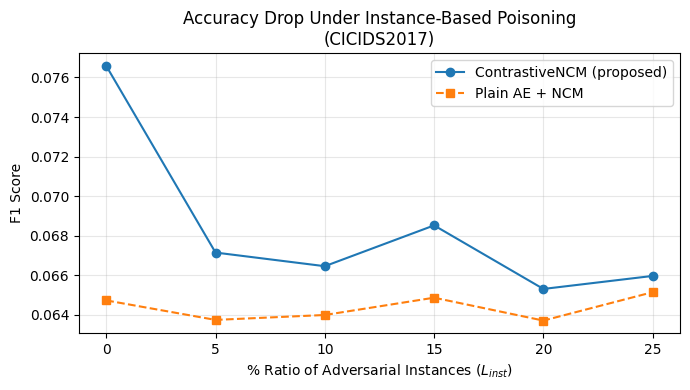

In [18]:
import matplotlib.pyplot as plt

l_vals  = [r[0] for r in results_c]
f1_c    = [r[3] for r in results_c]
f1_p    = [r[3] for r in results_p]

plt.figure(figsize=(7, 4))
plt.plot([v * 100 for v in l_vals], f1_c, marker='o', label='ContrastiveNCM (proposed)')
plt.plot([v * 100 for v in l_vals], f1_p, marker='s', linestyle='--', label='Plain AE + NCM')
plt.xlabel('% Ratio of Adversarial Instances ($L_{inst}$)')
plt.ylabel('F1 Score')
plt.title('Accuracy Drop Under Instance-Based Poisoning\n(CICIDS2017)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()